In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import csv
import lightkurve as lk

/Users/danayaptangco/opt/anaconda3/envs/Unruh3/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /Users/danayaptangco/.lightkurve/cache. Please move all the files in the legacy directory /Users/danayaptangco/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


In [ ]:
teff_ranges = [(4000, 6000)] #(4000, 5000), (5000, 6000), ]
rad_max = 4
rad_min = 1.5

df_combined = pd.DataFrame()
plt.figure(figsize=(10, 6))

df = pd.read_csv('TOI_Mar2025.csv', skiprows=0)


df = df.dropna(subset=['st_teff', 'pl_rade'])
df = df[(df['pl_rade'] < rad_max) & (df['pl_rade'] > rad_min)]

if 'tfopwg_disp' in df.columns:
    df = df[df['tfopwg_disp'] != 'FP']

for teff_min, teff_max in teff_ranges:
    df_filtered = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
    df_combined = pd.concat([df_combined, df_filtered], ignore_index=True)

    print(df_combined)
# Save the filtered DataFrame to a CSV file
    cdpp_values = {}

    for tid in df_combined['tid']:
        try:
            # Search and download
            search_result = lk.search_lightcurve(f"TIC {int(tid)}", cadence="short")
            if len(search_result) == 0:
                print(f"No lightcurve found for TIC {int(tid)}.")
                cdpp_values[tid] = None
                continue

            # Download and stitch
            most_recent_sector = search_result[-1]
            stitched_lc = most_recent_sector.download(quality_bitmask='hard')

            # Estimate CDPP
            cdpp = stitched_lc.estimate_cdpp() #The transit duration in units of number of cadences. This is the length of the window used to compute the running mean. The default is 13, which corresponds to a 6.5 hour transit in data sampled at 30-min cadence.
            print(f"CDPP for TIC {int(tid)}: {cdpp:.2f}")
            cdpp_values[tid] = cdpp

        except Exception as e:
            print(f"Error processing TIC {int(tid)}: {e}")
            cdpp_values[tid] = None

            # Fix for corrupted file: remove its directory from cache
            try:
                # Get download directory from search result
                download_dir = search_result[0].download().path.parent
                print(f"Removing corrupted file directory: {download_dir}")
                import shutil
                shutil.rmtree(download_dir)
            except Exception as cleanup_error:
                print(f"Cleanup failed for TIC {int(tid)}: {cleanup_error}")

    # Add CDPP values to the DataFrame
    df_combined['cdpp'] = df_combined['tid'].map(cdpp_values)

         toi        tid tfopwg_disp         rastr          ra         decstr  \
0    5165.01  349986198          PC  10h17m00.04s  154.250153  +06d51m59.32s   
1     512.01  119292328          CP  06h26m35.21s   96.646702  -38d36m25.96s   
2    7043.01   57299130          PC  16h47m13.48s  251.806160  +37d53m09.45s   
3    6944.01  421005422          PC  07h27m42.73s  111.928044  +09d58m10.38s   
4    6985.01   59490344          PC  07h15m58.52s  108.993831  +18d41m29.97s   
..       ...        ...         ...           ...         ...            ...   
807   871.01  219344917          PC  04h58m57.03s   74.737626  -50d37m38.69s   
808   875.01   14165625          PC  05h12m08.93s   78.037215  -37d42m30.53s   
809   880.02   34077285          PC  06h16m39.47s   94.164473  -13d59m14.41s   
810   880.03   34077285          PC  06h16m39.47s   94.164473  -13d59m14.41s   
811   942.01  146520535          CP  05h06m35.91s   76.649617  -20d14m44.21s   

           dec  st_pmra  st_pmraerr1  s

CDPP for TIC 158025009: 175.44 ppm
CDPP for TIC 233951353: 209.34 ppm
CDPP for TIC 130181866: 66.55 ppm
CDPP for TIC 234388232: 361.61 ppm
CDPP for TIC 264979636: 321.45 ppm


CDPP for TIC 96165095: 818.10 ppm
CDPP for TIC 415399713: 323.69 ppm
CDPP for TIC 178266267: 225.46 ppm
CDPP for TIC 17385917: 437.14 ppm
CDPP for TIC 9707944: 404.38 ppm
CDPP for TIC 326470400: 466.78 ppm
CDPP for TIC 286864983: 417.73 ppm
CDPP for TIC 407126408: 190.60 ppm
CDPP for TIC 233087860: 250.35 ppm
CDPP for TIC 417676622: 151.87 ppm
CDPP for TIC 269701147: 5519.07 ppm
CDPP for TIC 269701147: 5519.07 ppm
CDPP for TIC 269701147: 5519.07 ppm
CDPP for TIC 293954617: 113.96 ppm
CDPP for TIC 198390247: 320.57 ppm
CDPP for TIC 219776325: 760.95 ppm
CDPP for TIC 219857012: 143.12 ppm
CDPP for TIC 233071822: 372.66 ppm


CDPP for TIC 103633672: 228.64 ppm
CDPP for TIC 165527918: 507.20 ppm
CDPP for TIC 233688779: 251.52 ppm
CDPP for TIC 283471501: 178.05 ppm
CDPP for TIC 418604868: 83.26 ppm


CDPP for TIC 281837575: 1704.86 ppm
CDPP for TIC 47601197: 430.82 ppm
CDPP for TIC 466382581: 216.20 ppm
CDPP for TIC 459735346: 120.30 ppm
CDPP for TIC 92439980: 176.18 ppm
CDPP for TIC 9166136: 325.37 ppm
CDPP for TIC 219852882: 473.31 ppm
CDPP for TIC 160428500: 315.18 ppm
CDPP for TIC 289218489: 150.27 ppm
CDPP for TIC 165337974: 534.73 ppm
CDPP for TIC 408548144: 1268.88 ppm
CDPP for TIC 351599985: 3173.66 ppm
CDPP for TIC 154869806: 1034.81 ppm
CDPP for TIC 468350765: 798.27 ppm
CDPP for TIC 404518509: 117.20 ppm
CDPP for TIC 422914082: 253.11 ppm
CDPP for TIC 328933398: 455.95 ppm
CDPP for TIC 85292615: 241.74 ppm
CDPP for TIC 283884522: 172.79 ppm
CDPP for TIC 158002130: 245.29 ppm
CDPP for TIC 23961340: 127.24 ppm
CDPP for TIC 52368076: 263.85 ppm
CDPP for TIC 251848941: 518.55 ppm
CDPP for TIC 320004517: 106.89 ppm


...

CDPP for TIC 262880065: 293.65 ppm
CDPP for TIC 55315929: 159.47 ppm
CDPP for TIC 158241252: 248.52 ppm
CDPP for TIC 233182695: 191.41 ppm
CDPP for TIC 77253676: 165.93 ppm
CDPP for TIC 464646604: 136.32 ppm
CDPP for TIC 273985865: 879.44 ppm
CDPP for TIC 59582240: 229.05 ppm
CDPP for TIC 149845414: 125.58 ppm
CDPP for TIC 167905035: 103.49 ppm
CDPP for TIC 277697921: 1253.78 ppm
CDPP for TIC 53287554: 356.58 ppm
CDPP for TIC 260647166: 130.01 ppm
CDPP for TIC 219778329: 132.40 ppm
CDPP for TIC 165554103: 642.17 ppm
CDPP for TIC 241442273: 141.62 ppm
CDPP for TIC 260417932: 289.41 ppm
CDPP for TIC 451645081: 207.33 ppm
CDPP for TIC 144297844: 742.35 ppm
CDPP for TIC 382980571: 455.94 ppm
CDPP for TIC 149969625: 393.27 ppm
CDPP for TIC 159400561: 277.69 ppm
CDPP for TIC 175236511: 794.87 ppm
CDPP for TIC 63898957: 160.93 ppm
CDPP for TIC 13883872: 252.00 ppm
CDPP for TIC 94986319: 195.96 ppm
CDPP for TIC 404421005: 216.35 ppm
CDPP for TIC 123664207: 609.83 ppm
CDPP for TIC 317134140: 86

CDPP for TIC 212253390: 222.23 ppm
CDPP for TIC 326453034: 407.07 ppm


CDPP for TIC 310231275: 166.82 ppm
CDPP for TIC 91555165: 281.34 ppm
CDPP for TIC 97486178: 314.37 ppm
CDPP for TIC 142937186: 162.56 ppm
CDPP for TIC 420051632: 182.24 ppm
CDPP for TIC 298164705: 273.75 ppm
CDPP for TIC 67782629: 334.83 ppm
CDPP for TIC 311271011: 286.62 ppm
CDPP for TIC 248650906: 196.20 ppm
CDPP for TIC 262435954: 342.50 ppm
CDPP for TIC 262258341: 420.68 ppm
No lightcurve found for TIC 117938087.
CDPP for TIC 354519019: 166.21 ppm
CDPP for TIC 47720259: 337.97 ppm
CDPP for TIC 443213925: 328.11 ppm
CDPP for TIC 63898957: 160.93 ppm
CDPP for TIC 122613513: 322.70 ppm
CDPP for TIC 316769613: 582.96 ppm
CDPP for TIC 7422496: 134.21 ppm
CDPP for TIC 65416038: 342.66 ppm
CDPP for TIC 72668830: 309.02 ppm
CDPP for TIC 28116365: 372.90 ppm
CDPP for TIC 122617317: 348.35 ppm
CDPP for TIC 77175217: 88.93 ppm
CDPP for TIC 237332812: 166.24 ppm
CDPP for TIC 332715376: 250.72 ppm
CDPP for TIC 325682877: 454.80 ppm
CDPP for TIC 178170828: 435.34 ppm
CDPP for TIC 208297760: 401.

CDPP for TIC 326386495: 282.31 ppm
CDPP for TIC 257605131: 295.99 ppm
CDPP for TIC 257605131: 295.99 ppm
CDPP for TIC 257605131: 295.99 ppm
CDPP for TIC 262715204: 901.63 ppm
CDPP for TIC 64071894: 218.54 ppm
CDPP for TIC 100608026: 352.92 ppm
CDPP for TIC 50618703: 212.61 ppm
CDPP for TIC 161477033: 242.89 ppm
CDPP for TIC 161477033: 242.89 ppm
CDPP for TIC 344926234: 143.00 ppm
CDPP for TIC 286132427: 94.95 ppm
CDPP for TIC 150247134: 695.65 ppm
CDPP for TIC 219401954: 206.72 ppm
CDPP for TIC 277099925: 383.80 ppm
CDPP for TIC 179308757: 4039.08 ppm
CDPP for TIC 30122649: 223.98 ppm
CDPP for TIC 149301575: 217.95 ppm
No lightcurve found for TIC 33595516.
CDPP for TIC 219344917: 199.37 ppm
CDPP for TIC 14165625: 642.05 ppm
CDPP for TIC 34077285: 279.22 ppm
CDPP for TIC 34077285: 279.22 ppm
CDPP for TIC 146520535: 435.79 ppm


<Figure size 1000x600 with 0 Axes>

         toi        tid tfopwg_disp         rastr          ra         decstr  \
0    5165.01  349986198          PC  10h17m00.04s  154.250153  +06d51m59.32s   
1     512.01  119292328          CP  06h26m35.21s   96.646702  -38d36m25.96s   
2    7043.01   57299130          PC  16h47m13.48s  251.806160  +37d53m09.45s   
3    6944.01  421005422          PC  07h27m42.73s  111.928044  +09d58m10.38s   
4    6985.01   59490344          PC  07h15m58.52s  108.993831  +18d41m29.97s   
..       ...        ...         ...           ...         ...            ...   
807   871.01  219344917          PC  04h58m57.03s   74.737626  -50d37m38.69s   
808   875.01   14165625          PC  05h12m08.93s   78.037215  -37d42m30.53s   
809   880.02   34077285          PC  06h16m39.47s   94.164473  -13d59m14.41s   
810   880.03   34077285          PC  06h16m39.47s   94.164473  -13d59m14.41s   
811   942.01  146520535          CP  05h06m35.91s   76.649617  -20d14m44.21s   

           dec  st_pmra  st_pmraerr1  s

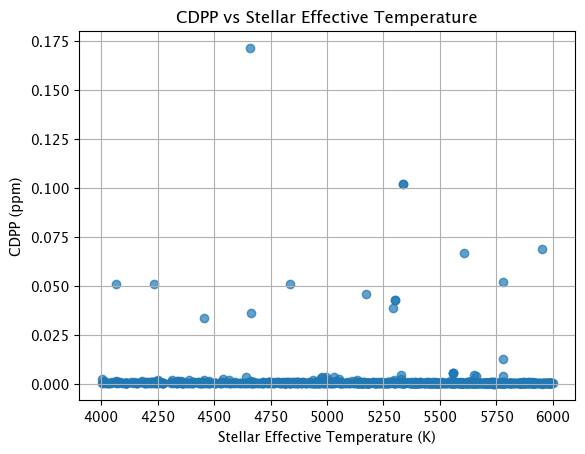

In [11]:
#df_combined['cdpp'] = df_combined['tid'].map(cdpp_values)
print(df_combined)

plt.scatter(df_combined['st_teff'], df_combined['cdpp'], alpha=0.7)
plt.xlabel('Stellar Effective Temperature (K)')
plt.ylabel('CDPP (ppm)')
plt.title('CDPP vs Stellar Effective Temperature')
plt.grid(True)
plt.show()

In [14]:
# Load the original CSV
df_original = pd.read_csv('TOI_Mar2025.csv', skiprows=0)


# Step 1: Aggregate df_combined to make sure each 'tid' maps to a single cdpp value
cdpp_map = df_combined.groupby('tid')['cdpp'].mean()

# Step 2: Only fill in missing values in df_original['cdpp'] using the tid map
df_original['cdpp'] = df_original['cdpp'].fillna(df_original['tid'].map(cdpp_map))

print(df_original)

# Remove duplicate rows
df_original = df_original.drop_duplicates()

# Step 3: Save the updated DataFrame
df_original.to_csv('TOI_Mar2025.csv', index=False)

          toi        tid tfopwg_disp         rastr          ra         decstr  \
0     4265.01  118308828          FP  08h34m48.37s  128.701521  -56d19m54.58s   
1     1600.01  187029841          FP  02h18m13.43s   34.555963  +38d28m43.77s   
2     2997.01   35652085          PC  09h54m54.01s  148.725050   -43d41m18.5s   
3     7137.01  161687209          FP  15h44m13.02s  236.054241  +58d33m13.28s   
4     4267.01   80783538         APC  11h04m16.86s  166.070243  -49d49m17.39s   
...       ...        ...         ...           ...         ...            ...   
8372   988.01  113553629          FP  07h33m41.77s  113.424039  -30d59m45.79s   
8373   992.01  108835813          FP  07h30m28.01s  112.616704  -26d04m50.46s   
8374   994.01   93963408          FP  07h40m11.12s  115.046333  -09d05m03.37s   
8375   995.01  317951248          FP  07h23m14.75s  110.811443  +05d33m46.26s   
8376   996.01  142918609          FP  07h57m23.99s  119.349948  -19d30m57.65s   

            dec  st_pmra  s